In [1]:
import os # For navigating through folders
import matplotlib.pyplot as plt # For drawing the EDA chart
import matplotlib.image as mpimg # To open and read image files

In [2]:
# Dataset path
base_dir = r'C:\Users\vinuga janandith\Desktop\AIML project\data'

# Trackers for our data
class_counts = {}
corrupted_files = []

print("Checking dataset for broken images...")

# Loop through all folders to find images
for root, dirs, files in os.walk(base_dir):
    if not dirs: # Only look inside the final subfolders
        class_name = os.path.basename(root)
        valid_count = 0
        
        for file in files:
            # Check if the file is an image
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                file_path = os.path.join(root, file)
                
                # Try to open the image. If it fails, mark it as corrupted.
                try:
                    img = mpimg.imread(file_path)
                    if img is None:
                        corrupted_files.append(file_path)
                    else:
                        valid_count += 1 
                except Exception:
                    corrupted_files.append(file_path)
        
        # Save the valid image count for this class
        if valid_count > 0:
            class_counts[class_name] = valid_count

# Print results
print("-" * 40)
print(f"Total broken images found: {len(corrupted_files)}")
if len(corrupted_files) > 0:
    for bad_file in corrupted_files[:5]: 
        print(f" - {bad_file}")
print("-" * 40)

Checking dataset for broken images...
----------------------------------------
Total broken images found: 0
----------------------------------------


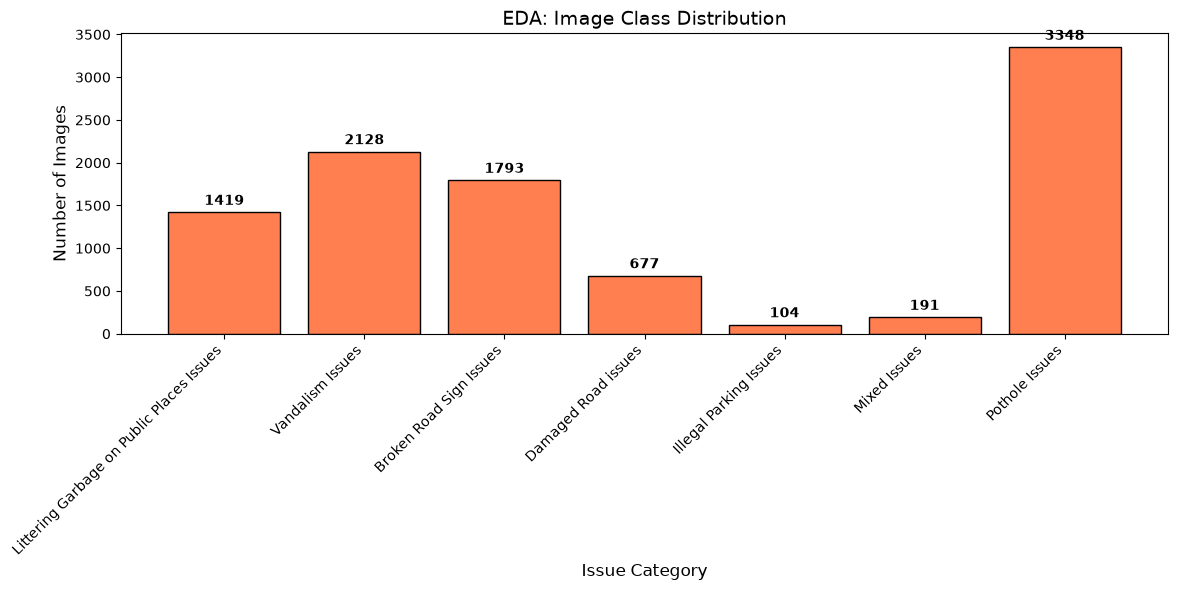

In [3]:
# Plot the EDA bar chart
plt.figure(figsize=(12, 6))
plt.bar(class_counts.keys(), class_counts.values(), color='coral', edgecolor='black')
plt.xticks(rotation=45, ha='right')

plt.title('EDA: Image Class Distribution', fontsize=14)
plt.xlabel('Issue Category', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)

# Put the exact count on top of the bars
for i, (classname, count) in enumerate(class_counts.items()):
    plt.text(i, count + 50, str(count), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()